In [1]:
import pandas as pd

df = pd.read_csv("European_Bank.csv")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

# Check number of unique customers
print("\nUnique Customer IDs:")
print(df["CustomerId"].nunique())

Missing values:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows:
0

Unique Customer IDs:
10000


In [3]:
# Check column names and data types
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [4]:
print("Geography:")
print(df["Geography"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())

print("\nNumber of Products:")
print(df["NumOfProducts"].value_counts().sort_index())

print("\nActive Member:")
print(df["IsActiveMember"].value_counts())

print("\nCredit Card:")
print(df["HasCrCard"].value_counts())

print("\nExited:")
print(df["Exited"].value_counts())

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Number of Products:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Active Member:
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

Credit Card:
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

Exited:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [5]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
# Create a working copy of the original dataset
data = df.copy()

print("Working dataset created.")
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Working dataset created.
Rows: 10000
Columns: 14


In [7]:
# Calculate overall customer churn rate

churn_rate = data["Exited"].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 20.37%


In [8]:
# Calculate churn rate by gender

gender_churn = data.groupby("Gender")["Exited"].mean() * 100

print("Churn Rate by Gender:")
print(gender_churn)

Churn Rate by Gender:
Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


In [9]:
# Calculate churn rate by geography

geography_churn = data.groupby("Geography")["Exited"].mean() * 100

print("Churn Rate by Geography:")
print(geography_churn)

Churn Rate by Geography:
Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


In [10]:
# Calculate churn rate by number of products

products_churn = data.groupby("NumOfProducts")["Exited"].mean() * 100

print("Churn Rate by Number of Products:")
print(products_churn)

Churn Rate by Number of Products:
NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [11]:
# Calculate churn rate by active membership

active_churn = data.groupby("IsActiveMember")["Exited"].mean() * 100

print("Churn Rate by Active Membership:")
print(active_churn)

Churn Rate by Active Membership:
IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [12]:
# Calculate churn rate by credit card ownership

card_churn = data.groupby("HasCrCard")["Exited"].mean() * 100

print("Churn Rate by Credit Card Ownership:")
print(card_churn)

Churn Rate by Credit Card Ownership:
HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64


In [13]:
# Create age groups

data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

# Calculate churn rate by age group

age_churn = data.groupby("AgeGroup", observed=False)["Exited"].mean() * 100

print("Churn Rate by Age Group:")
print(age_churn)

Churn Rate by Age Group:
AgeGroup
18-30     7.502569
31-40    12.087171
41-50    33.965517
51-60    56.210790
60+      24.784483
Name: Exited, dtype: float64


In [14]:
# Calculate churn rate by tenure

tenure_churn = data.groupby("Tenure")["Exited"].mean() * 100

print("Churn Rate by Tenure:")
print(tenure_churn)

Churn Rate by Tenure:
Tenure
0     23.002421
1     22.415459
2     19.179389
3     21.110010
4     20.525784
5     20.652174
6     20.268873
7     17.217899
8     19.219512
9     21.646341
10    20.612245
Name: Exited, dtype: float64


In [15]:
# Create salary groups

data["SalaryGroup"] = pd.qcut(
    data["EstimatedSalary"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

# Calculate churn rate by salary group

salary_churn = data.groupby("SalaryGroup", observed=False)["Exited"].mean() * 100

print("Churn Rate by Salary Group:")
print(salary_churn)

Churn Rate by Salary Group:
SalaryGroup
Low            20.00
Medium-Low     19.80
Medium-High    20.12
High           21.56
Name: Exited, dtype: float64


In [16]:
# Churn rate by number of products and active membership

products_active_churn = data.groupby(
    ["NumOfProducts", "IsActiveMember"]
)["Exited"].mean() * 100

print("Churn Rate by Number of Products and Active Membership:")
print(products_active_churn)

Churn Rate by Number of Products and Active Membership:
NumOfProducts  IsActiveMember
1              0                  36.652122
               1                  18.923137
2              0                   9.888060
               1                   5.560098
3              0                  88.235294
               1                  75.221239
4              0                 100.000000
               1                 100.000000
Name: Exited, dtype: float64


In [17]:
# Prepare data for churn prediction

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Make a copy of the dataset
model_data = data.copy()

# Encode categorical columns
le_geo = LabelEncoder()
le_gender = LabelEncoder()

model_data["Geography"] = le_geo.fit_transform(model_data["Geography"])
model_data["Gender"] = le_gender.fit_transform(model_data["Gender"])

# Remove unnecessary columns
model_data = model_data.drop(
    ["RowNumber", "CustomerId", "Surname", "AgeGroup", "SalaryGroup"],
    axis=1,
    errors="ignore"
)

# Separate features and target
X = model_data.drop("Exited", axis=1)
y = model_data["Exited"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 11)
Testing data: (2000, 11)


In [18]:
# Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [19]:
# Make predictions on the test data

y_pred = rf_model.predict(X_test)

# Calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred) * 100

print(f"Model Accuracy: {accuracy:.2f}%")

Model Accuracy: 86.35%


In [20]:
# Confusion Matrix and Classification Report

from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1538   55]
 [ 218  189]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.77      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [21]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
            Feature  Importance
4               Age    0.238418
10  EstimatedSalary    0.146946
1       CreditScore    0.145940
6           Balance    0.139384
7     NumOfProducts    0.132871
5            Tenure    0.082310
9    IsActiveMember    0.038648
2         Geography    0.038132
8         HasCrCard    0.019085
3            Gender    0.018265
0              Year    0.000000


In [22]:
# Create a summary of key churn findings

summary = {
    "Overall Churn Rate": f"{churn_rate:.2f}%",
    "Female Churn Rate": "25.07%",
    "Male Churn Rate": "16.40%",
    "Germany Churn Rate": "32.44%",
    "Highest Age Group Churn": "51-60 (56.21%)",
    "Lowest Age Group Churn": "18-30 (7.50%)",
    "Model Accuracy": f"{accuracy:.2f}%",
    "Top Churn Prediction Factor": "Age"
}

for key, value in summary.items():
    print(f"{key}: {value}")

Overall Churn Rate: 20.37%
Female Churn Rate: 25.07%
Male Churn Rate: 16.40%
Germany Churn Rate: 32.44%
Highest Age Group Churn: 51-60 (56.21%)
Lowest Age Group Churn: 18-30 (7.50%)
Model Accuracy: 86.35%
Top Churn Prediction Factor: Age


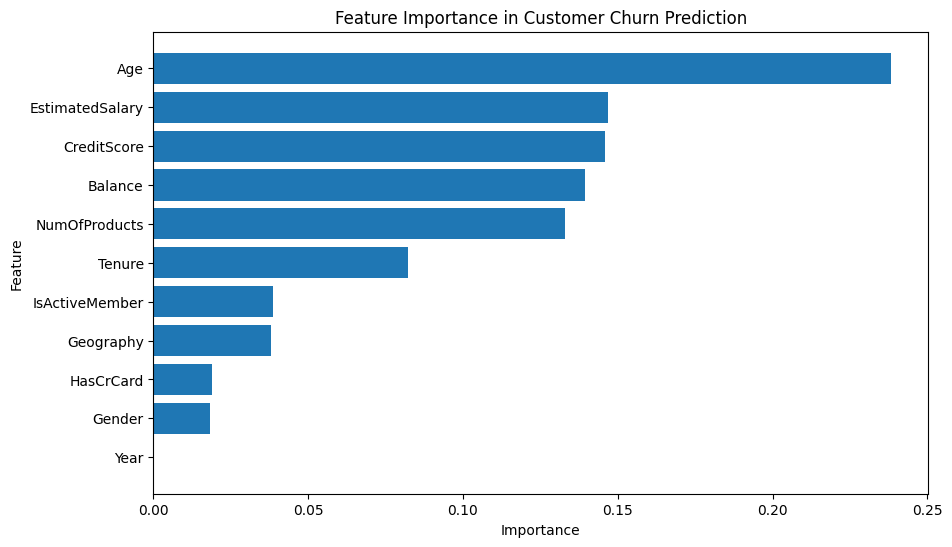

In [23]:
import matplotlib.pyplot as plt

# Plot feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Customer Churn Prediction")

plt.gca().invert_yaxis()
plt.show()

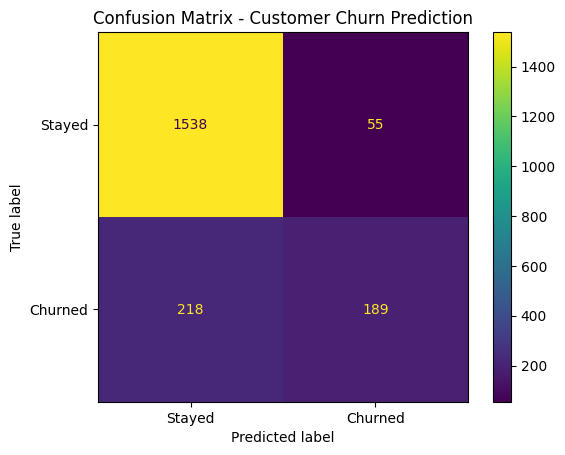

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix - Customer Churn Prediction")
plt.show()

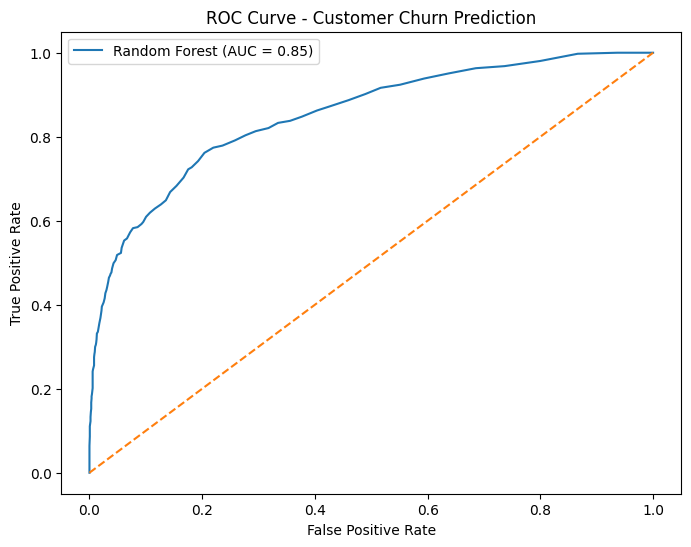

AUC Score: 0.85


In [25]:
# Plot ROC Curve and calculate AUC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability predictions
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.2f}")

Actual Churned Customers: 407
Predicted Churned Customers: 244


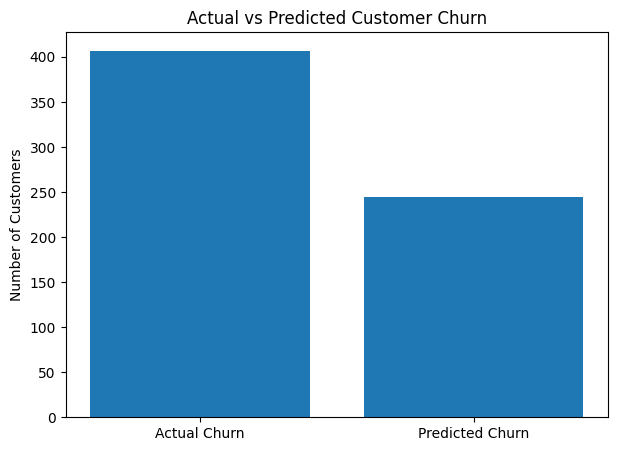

In [26]:
# Compare actual vs predicted churn

actual_churn = y_test.sum()
predicted_churn = y_pred.sum()

print(f"Actual Churned Customers: {actual_churn}")
print(f"Predicted Churned Customers: {predicted_churn}")

# Create comparison chart

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    ["Actual Churn", "Predicted Churn"],
    [actual_churn, predicted_churn]
)

plt.ylabel("Number of Customers")
plt.title("Actual vs Predicted Customer Churn")

plt.show()

In [27]:
# Create a high-risk customer profile

print("HIGH-RISK CUSTOMER PROFILE")
print("--------------------------")
print("Age group: 51-60")
print("Gender: Female")
print("Geography: Germany")
print("Membership: Inactive")
print("Overall churn rate: 20.37%")
print("Model accuracy: 86.35%")
print("AUC score: 0.85")

HIGH-RISK CUSTOMER PROFILE
--------------------------
Age group: 51-60
Gender: Female
Geography: Germany
Membership: Inactive
Overall churn rate: 20.37%
Model accuracy: 86.35%
AUC score: 0.85


In [28]:
# Customer churn prediction function

def predict_churn(customer_data):
    prediction = rf_model.predict(customer_data)

    if prediction[0] == 1:
        return "Customer is likely to CHURN"
    else:
        return "Customer is likely to STAY"

print("Churn prediction function created successfully!")

Churn prediction function created successfully!


In [29]:
# Test the churn prediction function with one test customer

sample_customer = X_test.iloc[[0]]

prediction = predict_churn(sample_customer)

print("Prediction:", prediction)

Prediction: Customer is likely to STAY


In [30]:
# Compare predicted result with actual result

actual_result = y_test.iloc[0]

print("Predicted:", prediction)
print("Actual:", "CHURN" if actual_result == 1 else "STAY")

Predicted: Customer is likely to STAY
Actual: STAY


In [31]:
# Calculate correct and incorrect predictions

correct_predictions = (y_pred == y_test).sum()
incorrect_predictions = (y_pred != y_test).sum()

print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {incorrect_predictions}")

Correct Predictions: 1727
Incorrect Predictions: 273


In [32]:
# Calculate correct and incorrect prediction percentages

correct_percentage = correct_predictions / len(y_test) * 100
incorrect_percentage = incorrect_predictions / len(y_test) * 100

print(f"Correct Prediction Percentage: {correct_percentage:.2f}%")
print(f"Incorrect Prediction Percentage: {incorrect_percentage:.2f}%")

Correct Prediction Percentage: 86.35%
Incorrect Prediction Percentage: 13.65%


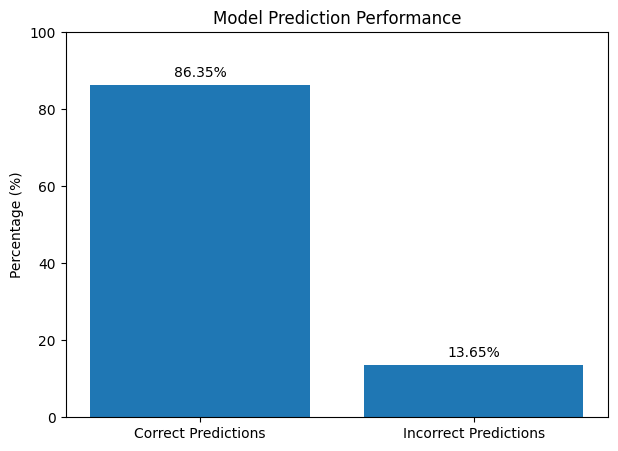

In [33]:
# Visualize model prediction performance

import matplotlib.pyplot as plt

labels = ["Correct Predictions", "Incorrect Predictions"]
values = [correct_percentage, incorrect_percentage]

plt.figure(figsize=(7, 5))
plt.bar(labels, values)

plt.ylabel("Percentage (%)")
plt.title("Model Prediction Performance")
plt.ylim(0, 100)

for i, value in enumerate(values):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.show()

In [34]:
# Save the trained Random Forest model

import joblib

joblib.dump(rf_model, "customer_churn_model.pkl")

print("Model saved successfully as customer_churn_model.pkl")

Model saved successfully as customer_churn_model.pkl


In [35]:
# Save the encoders

joblib.dump(le_geo, "geography_encoder.pkl")
joblib.dump(le_gender, "gender_encoder.pkl")

print("Encoders saved successfully!")

Encoders saved successfully!


In [36]:
# Save final model results

results = {
    "Overall Churn Rate": churn_rate,
    "Model Accuracy": accuracy,
    "AUC Score": auc_score,
    "Correct Predictions": correct_predictions,
    "Incorrect Predictions": incorrect_predictions
}

results_df = pd.DataFrame([results])

results_df.to_csv("churn_model_results.csv", index=False)

print("Results saved successfully as churn_model_results.csv")
print(results_df)

Results saved successfully as churn_model_results.csv
   Overall Churn Rate  Model Accuracy  AUC Score  Correct Predictions  \
0               20.37           86.35   0.850284                 1727   

   Incorrect Predictions  
0                    273  


In [37]:
# Final project summary

print("========== CUSTOMER CHURN PREDICTION ==========")
print(f"Overall Churn Rate      : {churn_rate:.2f}%")
print(f"Model Accuracy          : {accuracy:.2f}%")
print(f"AUC Score               : {auc_score:.2f}")
print(f"Correct Predictions     : {correct_predictions}")
print(f"Incorrect Predictions   : {incorrect_predictions}")
print()
print("Key Findings:")
print("- Female customers have higher churn than male customers.")
print("- Germany has the highest churn rate.")
print("- Customers aged 51-60 have the highest churn rate.")
print("- Age is the most important feature in the model.")
print("- Inactive members have higher churn than active members.")
print("===============================================")

========== CUSTOMER CHURN PREDICTION ==========
Overall Churn Rate      : 20.37%
Model Accuracy          : 86.35%
AUC Score               : 0.85
Correct Predictions     : 1727
Incorrect Predictions   : 273

Key Findings:
- Female customers have higher churn than male customers.
- Germany has the highest churn rate.
- Customers aged 51-60 have the highest churn rate.
- Age is the most important feature in the model.
- Inactive members have higher churn than active members.


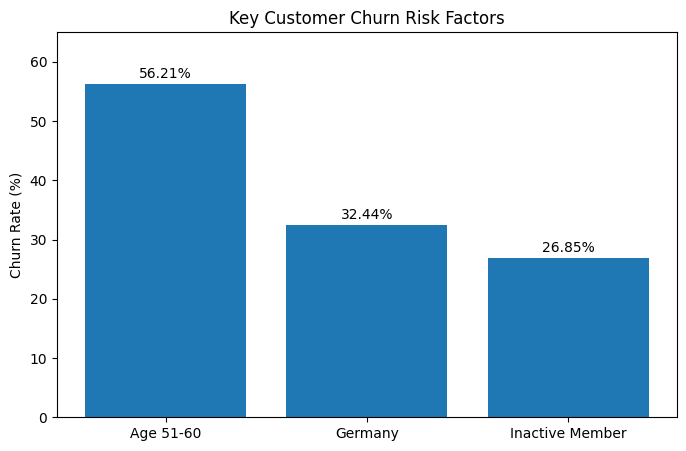

In [38]:
# Final churn-risk visualization

import matplotlib.pyplot as plt

categories = ["Age 51-60", "Germany", "Inactive Member"]
churn_rates = [56.21, 32.44, 26.85]

plt.figure(figsize=(8, 5))

plt.bar(categories, churn_rates)

plt.ylabel("Churn Rate (%)")
plt.title("Key Customer Churn Risk Factors")

for i, value in enumerate(churn_rates):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.ylim(0, 65)
plt.show()

In [39]:
# Create a project folder and save important files

import os
import shutil

project_folder = "Customer_Churn_Project"
os.makedirs(project_folder, exist_ok=True)

# Copy saved files into the project folder
shutil.copy("customer_churn_model.pkl", project_folder)
shutil.copy("geography_encoder.pkl", project_folder)
shutil.copy("gender_encoder.pkl", project_folder)
shutil.copy("churn_model_results.csv", project_folder)

print("All important project files saved successfully!")
print(f"Folder created: {project_folder}")

All important project files saved successfully!
Folder created: Customer_Churn_Project


In [40]:
# Create README file

readme_text = """
CUSTOMER CHURN PREDICTION USING MACHINE LEARNING

Project Overview:
This project analyzes customer data and predicts whether a customer is likely to churn.

Dataset:
Customer banking data containing demographic, account and activity information.

Key Findings:
- Overall churn rate: 20.37%
- Female churn rate: 25.07%
- Male churn rate: 16.40%
- Germany churn rate: 32.44%
- Highest age-group churn: 51-60 (56.21%)
- Lowest age-group churn: 18-30 (7.50%)

Machine Learning Model:
Random Forest Classifier

Model Performance:
- Accuracy: 86.35%
- AUC Score: 0.85

Most Important Feature:
Age

Conclusion:
The model can identify patterns associated with customer churn and can help
banks identify customers who may be at higher risk of leaving.
"""

with open("Customer_Churn_Project/README.txt", "w") as file:
    file.write(readme_text)

print("README created successfully!")

README created successfully!


In [41]:
# Create final results table

final_results = pd.DataFrame({
    "Metric": [
        "Overall Churn Rate",
        "Female Churn Rate",
        "Male Churn Rate",
        "Germany Churn Rate",
        "Highest Age Group Churn",
        "Lowest Age Group Churn",
        "Model Accuracy",
        "AUC Score"
    ],
    "Result": [
        "20.37%",
        "25.07%",
        "16.40%",
        "32.44%",
        "51-60 (56.21%)",
        "18-30 (7.50%)",
        "86.35%",
        "0.85"
    ]
})

print(final_results.to_string(index=False))

                 Metric         Result
     Overall Churn Rate         20.37%
      Female Churn Rate         25.07%
        Male Churn Rate         16.40%
     Germany Churn Rate         32.44%
Highest Age Group Churn 51-60 (56.21%)
 Lowest Age Group Churn  18-30 (7.50%)
         Model Accuracy         86.35%
              AUC Score           0.85


In [42]:
# Final project conclusion

print("""
CONCLUSION

The customer churn prediction project successfully analyzed customer
behavior and identified important factors associated with churn.

The overall customer churn rate was 20.37%. Female customers showed a
higher churn rate than male customers, while Germany had the highest
churn rate among the three countries.

Age was identified as the most important feature in the Random Forest
model, with customers aged 51-60 showing the highest churn rate.

The Random Forest model achieved an accuracy of 86.35% and an AUC score
of 0.85, demonstrating good predictive performance.

The results can help banks identify customers who are more likely to
churn and take preventive actions such as personalized offers,
improved customer service and targeted retention strategies.
""")


CONCLUSION

The customer churn prediction project successfully analyzed customer
behavior and identified important factors associated with churn.

The overall customer churn rate was 20.37%. Female customers showed a
higher churn rate than male customers, while Germany had the highest
churn rate among the three countries.

Age was identified as the most important feature in the Random Forest
model, with customers aged 51-60 showing the highest churn rate.

The Random Forest model achieved an accuracy of 86.35% and an AUC score
of 0.85, demonstrating good predictive performance.

The results can help banks identify customers who are more likely to
churn and take preventive actions such as personalized offers,
improved customer service and targeted retention strategies.



In [43]:
# Final project file checklist

import os

files = [
    "customer_churn_model.pkl",
    "geography_encoder.pkl",
    "gender_encoder.pkl",
    "churn_model_results.csv",
    "Customer_Churn_Project/README.txt"
]

print("PROJECT FILE CHECKLIST")
print("----------------------")

for file in files:
    if os.path.exists(file):
        print(f"✅ {file}")
    else:
        print(f"❌ {file}")

PROJECT FILE CHECKLIST
----------------------
✅ customer_churn_model.pkl
✅ geography_encoder.pkl
✅ gender_encoder.pkl
✅ churn_model_results.csv
✅ Customer_Churn_Project/README.txt


In [44]:
# Step 46: Train Logistic Regression for comparison

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_pred) * 100

# Calculate AUC
lr_prob = lr_model.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_prob)

print(f"Logistic Regression Accuracy: {lr_accuracy:.2f}%")
print(f"Logistic Regression AUC: {lr_auc:.2f}")

Logistic Regression Accuracy: 80.45%
Logistic Regression AUC: 0.77


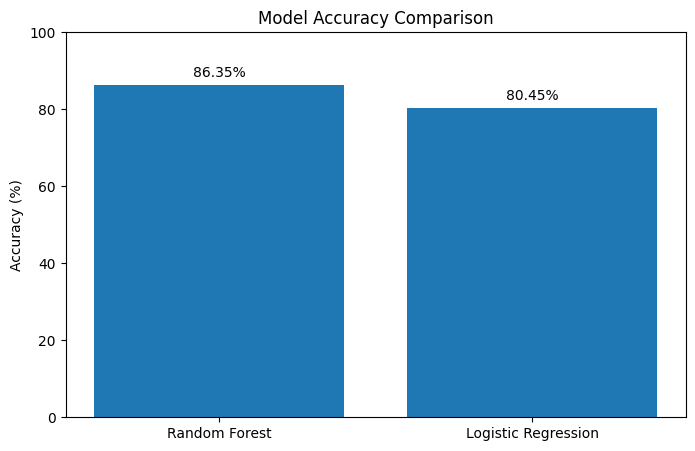

In [45]:
# Step 47: Compare model performance

import matplotlib.pyplot as plt

models = ["Random Forest", "Logistic Regression"]
accuracies = [accuracy, lr_accuracy]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

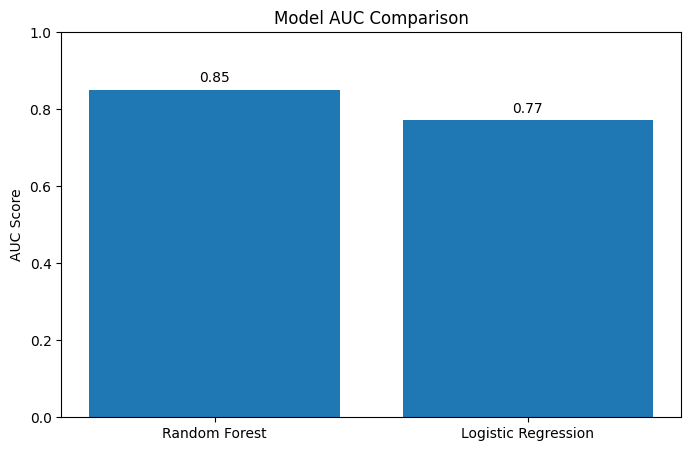

In [46]:
# Step 48: Compare AUC scores

models = ["Random Forest", "Logistic Regression"]
auc_scores = [auc_score, lr_auc]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, auc_scores)

plt.ylabel("AUC Score")
plt.title("Model AUC Comparison")
plt.ylim(0, 1)

for bar, value in zip(bars, auc_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

In [47]:
# Step 49: Final model comparison table

model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [accuracy, lr_accuracy],
    "AUC": [auc_score, lr_auc]
})

print(model_comparison.to_string(index=False))

              Model  Accuracy      AUC
      Random Forest     86.35 0.850284
Logistic Regression     80.45 0.771175


In [48]:
# Step 50: Save model comparison

model_comparison.to_csv(
    "Customer_Churn_Project/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [49]:
# Step 51: Final project dashboard summary

print("""
========================================
       CUSTOMER CHURN PREDICTION
========================================

DATASET INSIGHTS
----------------
Overall Churn Rate       : 20.37%
Female Churn Rate        : 25.07%
Male Churn Rate          : 16.40%
Germany Churn Rate       : 32.44%
Highest Age Group        : 51-60 (56.21%)

MODEL PERFORMANCE
-----------------
Random Forest Accuracy   : 86.35%
Random Forest AUC        : 0.85

Logistic Regression
Accuracy                 : 80.45%
AUC                      : 0.77

BEST MODEL
----------
Random Forest

TOP PREDICTION FACTOR
---------------------
Age

========================================
""")


       CUSTOMER CHURN PREDICTION

DATASET INSIGHTS
----------------
Overall Churn Rate       : 20.37%
Female Churn Rate        : 25.07%
Male Churn Rate          : 16.40%
Germany Churn Rate       : 32.44%
Highest Age Group        : 51-60 (56.21%)

MODEL PERFORMANCE
-----------------
Random Forest Accuracy   : 86.35%
Random Forest AUC        : 0.85

Logistic Regression
Accuracy                 : 80.45%
AUC                      : 0.77

BEST MODEL
----------
Random Forest

TOP PREDICTION FACTOR
---------------------
Age




In [50]:
# Step 52: Save final model performance

final_model_results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy (%)": [accuracy, lr_accuracy],
    "AUC Score": [auc_score, lr_auc]
})

final_model_results.to_csv(
    "Customer_Churn_Project/final_model_results.csv",
    index=False
)

print("Final model results saved successfully!")
print(final_model_results)

Final model results saved successfully!
                 Model  Accuracy (%)  AUC Score
0        Random Forest         86.35   0.850284
1  Logistic Regression         80.45   0.771175


In [51]:
# Step 53: Save feature importance table

feature_importance.to_csv(
    "Customer_Churn_Project/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")
print(feature_importance)

Feature importance saved successfully!
            Feature  Importance
4               Age    0.238418
10  EstimatedSalary    0.146946
1       CreditScore    0.145940
6           Balance    0.139384
7     NumOfProducts    0.132871
5            Tenure    0.082310
9    IsActiveMember    0.038648
2         Geography    0.038132
8         HasCrCard    0.019085
3            Gender    0.018265
0              Year    0.000000


In [52]:
# Step 54: Save churn analysis results

churn_analysis = pd.DataFrame({
    "Analysis": [
        "Overall Churn Rate",
        "Female Churn Rate",
        "Male Churn Rate",
        "Germany Churn Rate",
        "Highest Age Group Churn",
        "Lowest Age Group Churn",
        "Inactive Member Churn Rate",
        "Active Member Churn Rate"
    ],
    "Result": [
        "20.37%",
        "25.07%",
        "16.40%",
        "32.44%",
        "51-60 (56.21%)",
        "18-30 (7.50%)",
        "26.85%",
        "14.26%"
    ]
})

churn_analysis.to_csv(
    "Customer_Churn_Project/churn_analysis.csv",
    index=False
)

print("Churn analysis saved successfully!")
print(churn_analysis)

Churn analysis saved successfully!
                     Analysis          Result
0          Overall Churn Rate          20.37%
1           Female Churn Rate          25.07%
2             Male Churn Rate          16.40%
3          Germany Churn Rate          32.44%
4     Highest Age Group Churn  51-60 (56.21%)
5      Lowest Age Group Churn   18-30 (7.50%)
6  Inactive Member Churn Rate          26.85%
7    Active Member Churn Rate          14.26%


In [53]:
# Step 55: Create final project metrics

final_metrics = pd.DataFrame({
    "Metric": [
        "Overall Churn Rate",
        "Model Accuracy",
        "Model AUC",
        "Best Model",
        "Top Feature",
        "Highest Churn Group",
        "Highest Churn Geography",
        "Inactive Member Churn"
    ],
    "Value": [
        "20.37%",
        "86.35%",
        "0.85",
        "Random Forest",
        "Age",
        "Age 51-60 (56.21%)",
        "Germany (32.44%)",
        "26.85%"
    ]
})

final_metrics.to_csv(
    "Customer_Churn_Project/final_project_metrics.csv",
    index=False
)

print("Final project metrics saved successfully!")
print(final_metrics)

Final project metrics saved successfully!
                    Metric               Value
0       Overall Churn Rate              20.37%
1           Model Accuracy              86.35%
2                Model AUC                0.85
3               Best Model       Random Forest
4              Top Feature                 Age
5      Highest Churn Group  Age 51-60 (56.21%)
6  Highest Churn Geography    Germany (32.44%)
7    Inactive Member Churn              26.85%


In [54]:
# Step 56: Create project ZIP file

import shutil

zip_file = shutil.make_archive(
    "Customer_Churn_Project",
    "zip",
    "Customer_Churn_Project"
)

print("Project ZIP created successfully!")
print(f"File: {zip_file}")

Project ZIP created successfully!
File: /content/Customer_Churn_Project.zip


In [55]:
# Step 57: Verify ZIP contents

import zipfile

with zipfile.ZipFile("Customer_Churn_Project.zip", "r") as zip_ref:
    print("Files inside the ZIP:")
    for file in zip_ref.namelist():
        print("✅", file)

Files inside the ZIP:
✅ final_project_metrics.csv
✅ churn_analysis.csv
✅ churn_model_results.csv
✅ geography_encoder.pkl
✅ model_comparison.csv
✅ README.txt
✅ customer_churn_model.pkl
✅ gender_encoder.pkl
✅ feature_importance.csv
✅ final_model_results.csv
